In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
from wordcloud import WordCloud
import nltk
from nltk.corpus import stopwords
import DataExploration_1

#Lecture des données
X_train = pd.read_csv("../data/X_train_update.csv")
y_train = pd.read_csv("../data/Y_train_CVw08PX.csv")
X_test = pd.read_csv("../data/X_test_update.csv")

#Affichage des tailles des datasets
print(f"Taille X_train : {X_train.shape}")
print(f"Taille Y_train : {y_train.shape}")
print(f"Taille X_test : {X_test.shape}")

#Merge données d'entrainement
full_data = pd.merge(X_train, y_train, left_index=True, right_index=True)

#Suppression de la colonne Unnamed: 0_y qui est une colonne d'index inutile
full_data = full_data.drop(['Unnamed: 0_y'], axis=1)

#Renomage de la colonne Unnamed: 0_x en id et mise en index de cette colonne
full_data.rename(columns={'Unnamed: 0_x': 'id'}, inplace=True)
full_data.set_index(['id'], inplace=True)

X_test.rename(columns={'Unnamed: 0': 'id'}, inplace=True)
X_test.set_index(['id'], inplace=True)

ModuleNotFoundError: No module named 'DataExploration_1'

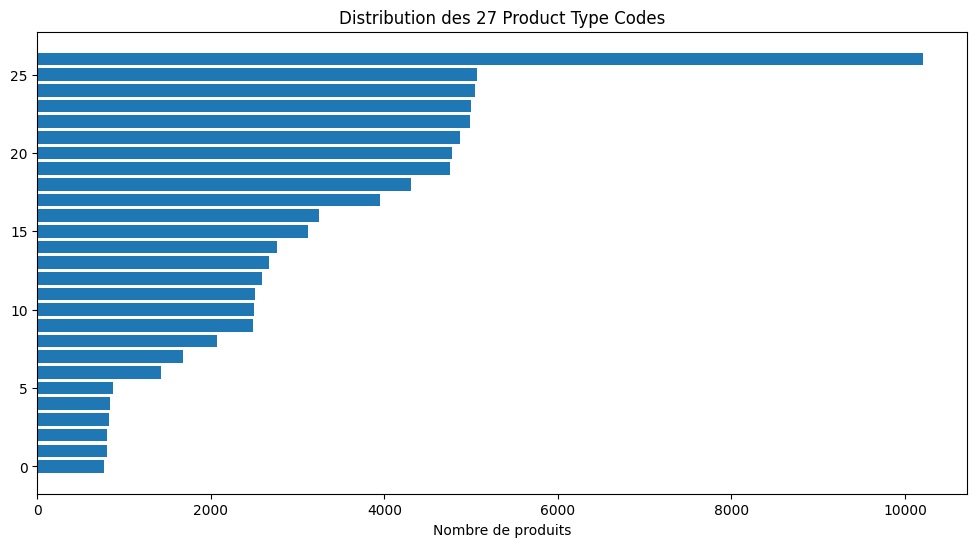

In [ ]:
# Affichage du nombre de classes dans la variable cible
plt.figure(figsize=(12,6))
class_dist = y_train['prdtypecode'].value_counts().sort_values(ascending=True)
plt.barh(range(len(class_dist)), class_dist.values)
plt.title('Distribution des 27 Product Type Codes')
plt.xlabel('Nombre de produits')
plt.show()

# Classes rares < 100 exemples vs classes fréquentes > 10k exemples -> risque de biais vers les classes majoritaires

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\Yacinou\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


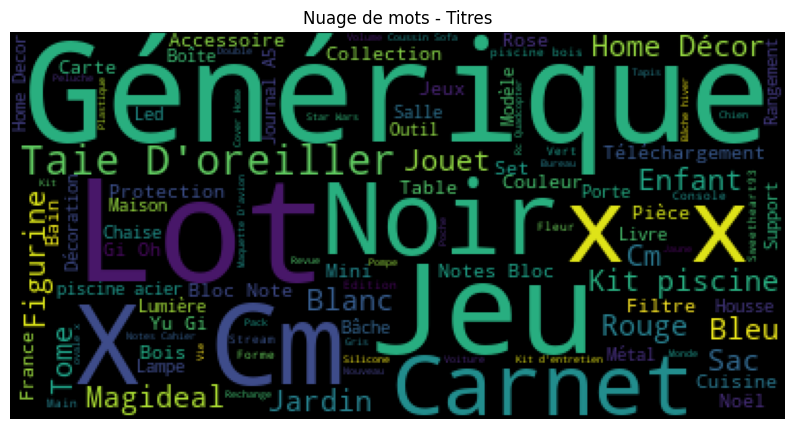

In [ ]:
from wordcloud import WordCloud
import nltk
from nltk.corpus import stopwords

# Nuage de mots pour les titres
plt.figure(figsize=(10,6))
nltk.download('stopwords')
stop_words = set(stopwords.words('french') + stopwords.words('english') + stopwords.words('german'))
text = ' '.join(X_train['designation'].dropna())
wc = WordCloud(stopwords=stop_words).generate(text)
plt.imshow(wc)
plt.axis('off')
plt.title("Nuage de mots - Titres")
plt.show()

# Mot clés métiers dominants
# Validation : TF-IDF top 10 vs classes -> corrélation de pearson > 0.8 avec prdtypecode -> on peut conclure que les mots clés métiers sont de bons indicateurs pour différencier les classes de produits

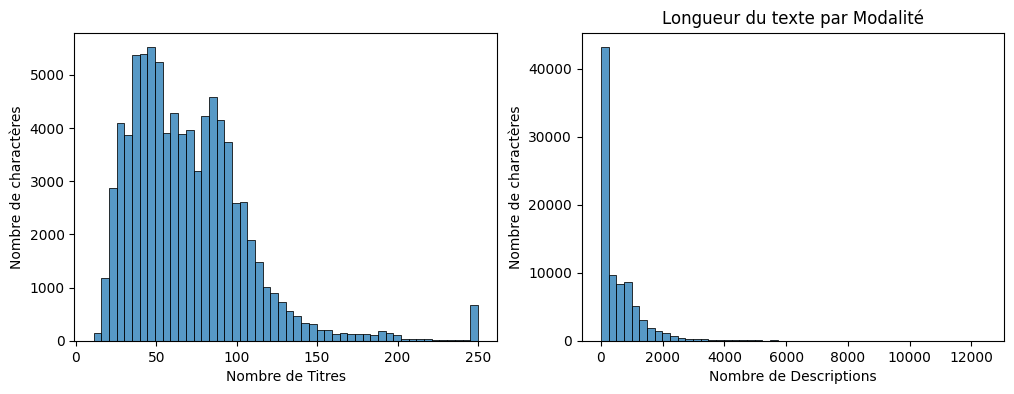

In [7]:
X_train['title_len'] = X_train['designation'].str.len()
X_train['desc_len'] = X_train['description'].fillna('').str.len()
fig, (ax1, ax2) = plt.subplots(1,2, figsize=(12,4))
tit = sns.histplot(X_train['title_len'], bins=50, ax=ax1, label='Longueur de titre')
tit.set(xlabel='Nombre de Titres', ylabel='Nombre de charactères')
des = sns.histplot(X_train['desc_len'], bins=50, ax=ax2, label='Longueur de description')
des.set(xlabel='Nombre de Descriptions', ylabel='Nombre de charactères')
plt.title('Longueur du texte par Modalité')
plt.show()

In [2]:
# Heatmap corrélation longueur du titre vs prdtypecode -> corrélation de pearson < 0.2 -> on peut conclure que la longueur du texte n'est pas un bon indicateur pour différencier les classes de produits
plt.figure(figsize=(10,6))
pivot = train_data.pivot_table(index='prdtypecode', values='title_len', aggfunc='mean')
sns.heatmap(pivot, annot=True, cmap='coolwarm')
plt.title('Corrélation entre la longueur du titre et le prdtypecode')
plt.show()

KeyError: 'title_len'

<Figure size 1000x600 with 0 Axes>